In [ ]:
  !pip install -U torchao peft transformers datasets sentencepiece accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.

Using device: cuda

⚠️ ACTION REQUIRED: PLEASE UPLOAD YOUR DATASETS ⚠️
Select both 'banking77_train.csv' and 'banking77_test.csv' from your local machine.


Saving banking77_test.csv to banking77_test (1).csv
Saving banking77_train.csv to banking77_train (1).csv

✅ Successfully loaded datasets!
Training size: (10003, 2)
Testing size: (3080, 2)
Number of banking intent labels: 77



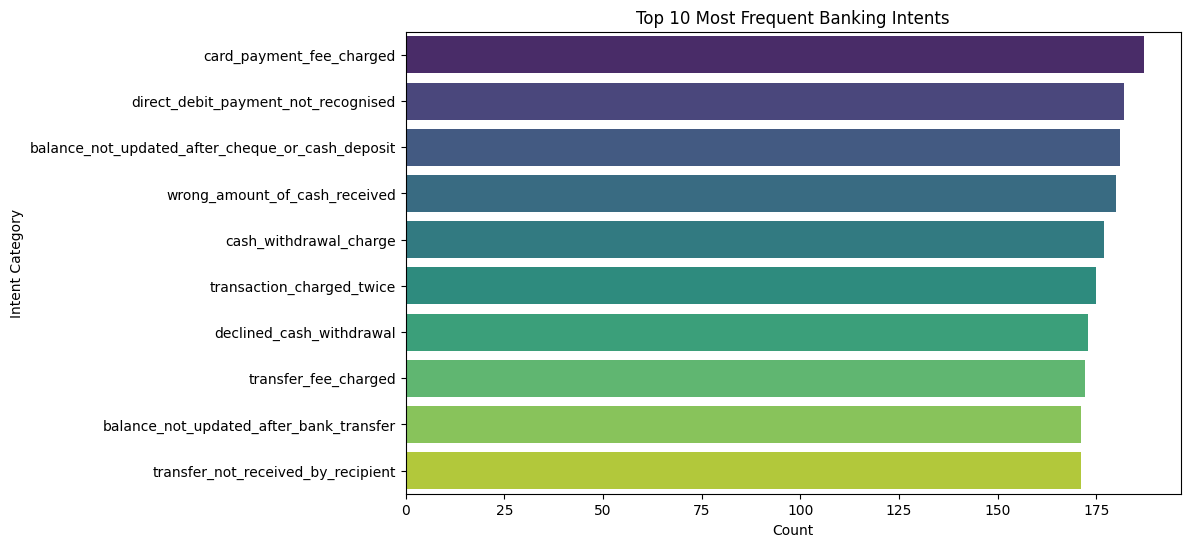

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import io
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# 1. Prompt for File Upload
print("⚠️ ACTION REQUIRED: PLEASE UPLOAD YOUR DATASETS ⚠️")
print("Select both 'banking77_train.csv' and 'banking77_test.csv' from your local machine.")
uploaded = files.upload()

# 2. Load the uploaded files into Pandas DataFrames
try:
    # Dynamically find the train and test files in the uploaded dictionary
    train_filename = [name for name in uploaded.keys() if 'train' in name.lower()][0]
    test_filename = [name for name in uploaded.keys() if 'test' in name.lower()][0]

    train = pd.read_csv(io.BytesIO(uploaded[train_filename]))
    test = pd.read_csv(io.BytesIO(uploaded[test_filename]))

    print(f"\n✅ Successfully loaded datasets!")
    print(f"Training size: {train.shape}")
    print(f"Testing size: {test.shape}")
    print(f"Number of banking intent labels: {train['category'].nunique()}\n")

    # 3. Exploratory Data Analysis (EDA)
    plt.figure(figsize=(10, 6))
    sns.countplot(y='category', data=train, order=train['category'].value_counts().iloc[:10].index, palette='viridis')
    plt.title("Top 10 Most Frequent Banking Intents")
    plt.xlabel("Count")
    plt.ylabel("Intent Category")
    plt.show()

except IndexError:
    print("\n❌ Error: Could not find both a training and testing file. Please re-run this cell and ensure you select both files.")

In [ ]:
import re

def redact_pii(text):
    # Redact standard credit card numbers
    text = re.sub(r'\b(?:\d[ -]*?){13,16}\b', '[REDACTED_CARD]', text)
    # Redact email addresses
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[REDACTED_EMAIL]', text)
    # Redact phone numbers
    text = re.sub(r'\b\d{3}[-.\s]??\d{3}[-.\s]??\d{4}\b', '[REDACTED_PHONE]', text)
    return text

# Apply PII redaction to both datasets
train['clean_text'] = train['text'].apply(redact_pii)
test['clean_text'] = test['text'].apply(redact_pii)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(train['category'])
y_test = le.transform(test['category'])

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train['clean_text'])
X_test_tfidf = tfidf.transform(test['clean_text'])

# Train MLP Classifier
mlp_model = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=20, random_state=42, early_stopping=True)
mlp_model.fit(X_train_tfidf, y_train)

# Predict and Evaluate
mlp_preds = mlp_model.predict(X_test_tfidf)
mlp_accuracy = accuracy_score(y_test, mlp_preds)
mlp_f1_macro = f1_score(y_test, mlp_preds, average='macro')

print(f"MLP Baseline Accuracy: {mlp_accuracy:.4f}")
print(f"MLP Baseline Macro F1: {mlp_f1_macro:.4f}")

MLP Baseline Accuracy: 0.8756
MLP Baseline Macro F1: 0.8764


In [ ]:
# 1. Install and upgrade necessary libraries
!pip install -U torchao peft transformers datasets

# 2. Import libraries
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")

# Convert pandas to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train[['clean_text', 'category']].rename(columns={'clean_text': 'text', 'category': 'label'}))
test_dataset = Dataset.from_pandas(test[['clean_text', 'category']].rename(columns={'clean_text': 'text', 'category': 'label'}))

# Encode labels for HF dataset
train_dataset = train_dataset.map(lambda x: {'label': le.transform([x['label']])[0]})
test_dataset = test_dataset.map(lambda x: {'label': le.transform([x['label']])[0]})

# Tokenization
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Define LoRA Configuration (Optimized for deep learning accuracy)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=64,
    lora_alpha=128,
    lora_dropout=0.05,
    bias="none",
    target_modules=["query", "key", "value", "dense"] # Targeting extra modules for higher accuracy
)

# Load Model and Apply LoRA
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=77)
peft_model = get_peft_model(model, lora_config)

# Define Training Arguments for 25 Epochs
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",        # Guarantees a log printout every single epoch
    save_strategy="epoch",           # Required to keep the most accurate model
    learning_rate=1e-4,              # Slightly lowered for a smooth 25-epoch descent
    per_device_train_batch_size=32,  # Lowered from 128 to prevent OOM and fix the logging gap
    num_train_epochs=10,             # 10 Epoch limit
    weight_decay=0.01,
    warmup_ratio=0.1,                # 10% warmup to stabilize initial weights
    lr_scheduler_type="cosine",      # Smoothly glides the learning rate down for steady loss decrease
    load_best_model_at_end=True,     # Automatically rewinds to the most accurate epoch
    metric_for_best_model="eval_loss",
    report_to="none"
)

# Train the model (With Early Stopping injection)
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)] # Stops training if it starts memorizing instead of learning
)

print("🔥 Starting Precision Training...")
trainer.train()

# Get Predictions
print("\n📊 Evaluating Final Model...")
raw_preds = trainer.predict(tokenized_test)
roberta_preds = np.argmax(raw_preds.predictions, axis=1)

roberta_accuracy = accuracy_score(y_test, roberta_preds)
roberta_f1_macro = f1_score(y_test, roberta_preds, average='macro')

print("\n==========================================")
print(f"🏆 MAXIMIZED LoRA-RoBERTa Accuracy: {roberta_accuracy:.4f}")
print(f"🏆 MAXIMIZED LoRA-RoBERTa Macro F1: {roberta_f1_macro:.4f}")
print("==========================================")

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,3.415089,1.397201


Epoch,Training Loss,Validation Loss
1,3.415089,1.397201
2,0.789227,0.414753
3,0.346797,0.325839
4,0.221006,0.286955
5,0.155565,0.266035
6,0.109247,0.271879
7,0.074883,0.251276
8,0.054518,0.258337
9,0.041878,0.257204
10,0.037782,0.257054



📊 Evaluating Final Model...



🏆 MAXIMIZED LoRA-RoBERTa Accuracy: 0.9380
🏆 MAXIMIZED LoRA-RoBERTa Macro F1: 0.9380
